In [1]:
import pandas as pd
import numpy as np

In [2]:
import chardet

with open("cleaned_seismic1.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [3]:
seismic_df = pd.read_csv("cleaned_seismic1.csv",  encoding='ISO-8859-1')
seismic_df

,Seismic Zone,PGA (m/s²),PGV (m/s),PGD (m),Spectral Acceleration (g),Soil Type,Site Amplification Factor,Historical Earthquake Magnitude (Mw),Fault Distance (km),Seismic Wave Frequency (Hz),...,Mass of Structure (kg),Axial Stiffness (kN/m),Bending Stiffness (kN·m²),Lateral Load Resisting System,Predicted Max Inter-Story Drift Ratio (%),Predicted Max Roof Displacement (m),Predicted Base Shear Force (kN),Predicted Structural Acceleration (m/s²),Predicted Damage Index (01 Scale),Predicted Collapse Probability (%)
0,0,0.378901,0.312027,0.057183,0.634076,2,0.939157,6.875154,22.203449,1.683141,...,737892.38060,3150.171653,25771.750960,1,2.126096,0.839807,3927.940393,0.767494,0.804542,80.454180
1,3,1.346301,1.255807,0.204481,1.728551,0,1.089761,6.829334,6.947244,4.041680,...,68704.84638,3245.337590,32856.945000,1,2.880256,1.530932,2923.719143,1.848156,0.706411,70.641053
2,1,0.502373,0.633995,0.443304,0.156820,1,2.689239,7.100447,33.224830,5.841681,...,705858.69300,7518.106276,16777.171280,1,2.762881,0.796000,180.446915,4.455967,0.795635,79.563529
3,0,0.614900,0.429642,0.024551,1.085648,1,2.194323,7.871919,15.225075,9.485727,...,937792.30750,781.139234,3013.866452,0,2.965618,1.303857,4136.426423,3.787915,0.766775,76.677520
4,0,0.181329,0.821528,0.480747,0.383056,1,1.357043,8.841107,71.283374,0.780634,...,728244.97580,4118.984745,25287.554730,0,0.819418,1.519645,926.867918,1.460147,0.205368,20.536788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0.134960,1.374925,0.029051,0.358366,1,2.716129,5.635004,70.917017,7.075402,...,368423.97280,4686.711203,44596.512310,0,3.721604,0.334625,4588.311350,3.356674,0.458558,45.855848
996,1,0.728654,1.424346,0.374013,0.321541,2,1.553135,8.148287,78.482505,1.082026,...,369161.28580,8067.613896,20357.781910,1,1.562331,0.038239,3821.131803,0.317926,0.646422,64.642205
997,3,0.432470,0.789667,0.425576,0.687566,1,2.493499,8.762268,46.076523,9.097986,...,565425.58160,8683.726878,36165.271700,0,2.295841,0.882552,1688.343205,3.953573,0.761871,76.187113
998,3,0.169460,1.770631,0.143781,1.473094,0,2.034983,5.111697,70.109360,2.228723,...,232365.80870,8536.894335,47038.670460,2,1.690556,1.460479,2540.157807,4.572299,0.231115,23.111530


In [7]:
# === 4. Define Inputs & Targets ===
# Use all seismic + structural features as predictors (exclude any target columns)

X_B = seismic_df[[
    'Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)', 
    'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor', 
    'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
    'Seismic Wave Frequency (Hz)', 'Building Height (m)', 'Number of Stories', 
    'Structural Material', 'Foundation Type', 'Natural Frequency (Hz)', 
    'Damping Ratio (%)', 'Mass of Structure (kg)', 'Axial Stiffness (kN/m)', 
    'Bending Stiffness (kN·m²)', 'Lateral Load Resisting System'
]]

y_B_clf = seismic_df['collapse_risk']

# === 5. Encode Categorical Variables ===
X_B = pd.get_dummies(X_B, drop_first=True)
print(X_B.columns.intersection(['collapse_risk', 'Predicted Collapse Probability (%)', 'Predicted Damage Index (01 Scale)']))


Index([], dtype='object')



================ Random Forest Classifier ================
10-Fold CV Accuracy: 0.358 ± 0.059
ROC-AUC not available (no predict_proba).

Confusion Matrix:
 [[21  3 40]
 [12  6 40]
 [21 10 47]]

Classification Report:
               precision    recall  f1-score   support

        High      0.389     0.328     0.356        64
         Low      0.316     0.103     0.156        58
      Medium      0.370     0.603     0.459        78

    accuracy                          0.370       200
   macro avg      0.358     0.345     0.323       200
weighted avg      0.360     0.370     0.338       200



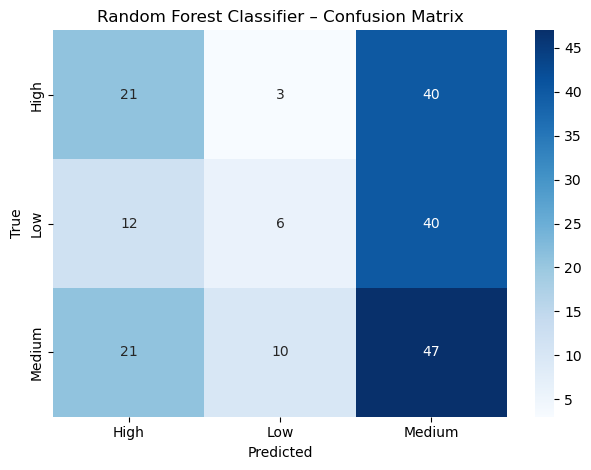


================ Support Vector Machine (SVM) ================
10-Fold CV Accuracy: 0.323 ± 0.047
ROC-AUC not available (no predict_proba).

Confusion Matrix:
 [[13 14 37]
 [ 8  8 42]
 [19 10 49]]

Classification Report:
               precision    recall  f1-score   support

        High      0.325     0.203     0.250        64
         Low      0.250     0.138     0.178        58
      Medium      0.383     0.628     0.476        78

    accuracy                          0.350       200
   macro avg      0.319     0.323     0.301       200
weighted avg      0.326     0.350     0.317       200



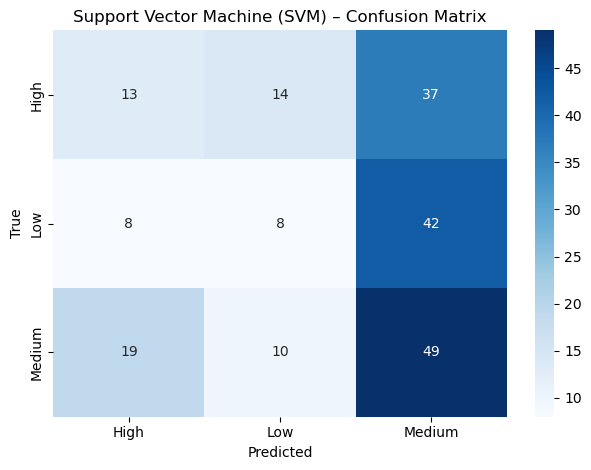


================ XGBoost Classifier ================
10-Fold CV Accuracy: 0.334 ± 0.041
ROC-AUC not available (no predict_proba).

Confusion Matrix:
 [[23 10 31]
 [18 15 25]
 [22 18 38]]

Classification Report:
               precision    recall  f1-score   support

        High      0.365     0.359     0.362        64
         Low      0.349     0.259     0.297        58
      Medium      0.404     0.487     0.442        78

    accuracy                          0.380       200
   macro avg      0.373     0.368     0.367       200
weighted avg      0.376     0.380     0.374       200



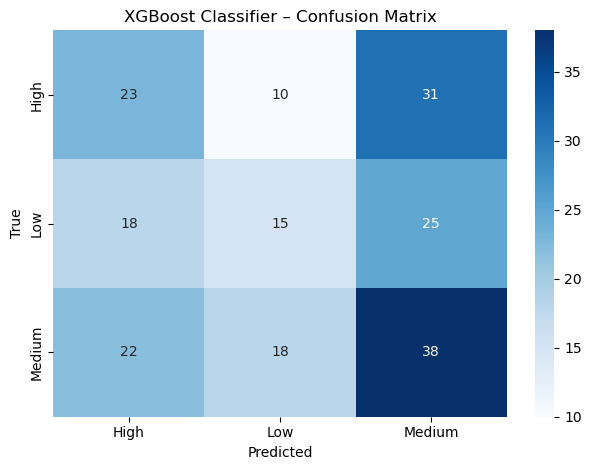


================ Logistic Regression Classifier ================
10-Fold CV Accuracy: 0.339 ± 0.046
ROC-AUC not available (no predict_proba).

Confusion Matrix:
 [[14 14 36]
 [12  7 39]
 [12 17 49]]

Classification Report:
               precision    recall  f1-score   support

        High      0.368     0.219     0.275        64
         Low      0.184     0.121     0.146        58
      Medium      0.395     0.628     0.485        78

    accuracy                          0.350       200
   macro avg      0.316     0.323     0.302       200
weighted avg      0.325     0.350     0.319       200



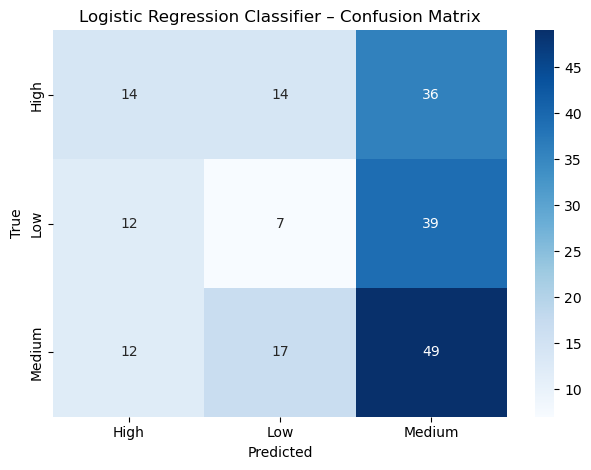

In [9]:
# === Sub-Problem B: Collapse Risk Classification (with 10-Fold CV) ===
# Author: Team AfterShock

# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load Dataset ===
seismic_df = pd.read_csv("cleaned_seismic1.csv",  encoding='ISO-8859-1')

# === 3. Prepare Targets ===
# Use the existing Predicted Collapse Probability (%) to create categorical risk
def classify_risk(prob):
    if prob < 30:
        return 'Low'
    elif 30 <= prob < 70:
        return 'Medium'
    elif prob > 70:
        return 'High'
    else: 
        return "Error"

seismic_df['collapse_risk'] = seismic_df['Predicted Collapse Probability (%)'].apply(classify_risk)

# === 4. Define Inputs & Targets ===
# Use all seismic + structural features as predictors (exclude any target columns)

X_B = seismic_df[[
    'Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)', 
    'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor', 
    'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
    'Seismic Wave Frequency (Hz)', 'Building Height (m)', 'Number of Stories', 
    'Structural Material', 'Foundation Type', 'Natural Frequency (Hz)', 
    'Damping Ratio (%)', 'Mass of Structure (kg)', 'Axial Stiffness (kN/m)', 
    'Bending Stiffness (kN·m²)', 'Lateral Load Resisting System'
]]

y_B_clf = seismic_df['collapse_risk']

# === 5. Encode Categorical Variables ===
X_B = pd.get_dummies(X_B, drop_first=True)

# === 6. Label Encode Target ===
le = LabelEncoder()
y_B_clf_encoded = le.fit_transform(y_B_clf)

# === 7. Train-Test Split ===
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B_clf_encoded, test_size=0.2, random_state=42, stratify=y_B_clf_encoded
)

# === 8. Feature Scaling (for SVM & Logistic Regression) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_B)
X_test_scaled = scaler.transform(X_test_B)


# === 9. Evaluation Function ===
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n================ {model_name} ================")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"10-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, digits=3)
    
    try:
        y_prob = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC (macro): {auc:.3f}")
    except:
        print("ROC-AUC not available (no predict_proba).")
    
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} – Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# === 10. Train & Evaluate Each Model ===

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
evaluate_model(rf, X_train_B, X_test_B, y_train_B, y_test_B, "Random Forest Classifier")

# Support Vector Machine
svm = SVC(kernel='rbf', probability=True, random_state=42)
evaluate_model(svm, X_train_scaled, X_test_scaled, y_train_B, y_test_B, "Support Vector Machine (SVM)")

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
evaluate_model(xgb, X_train_B, X_test_B, y_train_B, y_test_B, "XGBoost Classifier")

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model(logreg, X_train_scaled, X_test_scaled, y_train_B, y_test_B, "Logistic Regression Classifier")


================ Random Forest Classifier ================
10-Fold CV Accuracy: 0.366 ± 0.040
ROC-AUC (macro): 0.536

Confusion Matrix:
 [[20  8 36]
 [17 12 29]
 [20 10 48]]

Classification Report:
               precision    recall  f1-score   support

        High      0.351     0.312     0.331        64
         Low      0.400     0.207     0.273        58
      Medium      0.425     0.615     0.503        78

    accuracy                          0.400       200
   macro avg      0.392     0.378     0.369       200
weighted avg      0.394     0.400     0.381       200



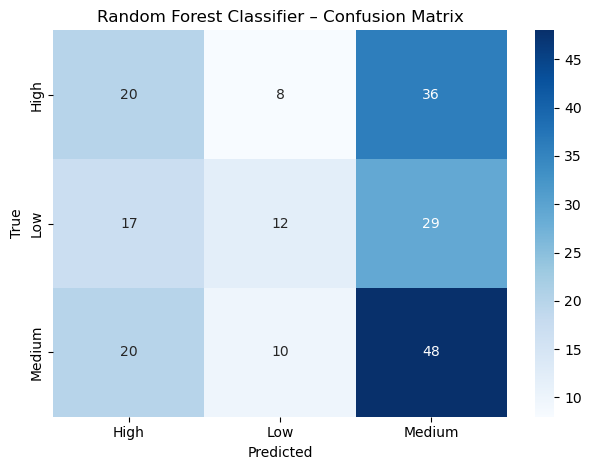


================ Support Vector Machine (SVM) ================
10-Fold CV Accuracy: 0.350 ± 0.022
ROC-AUC (macro): 0.537

Confusion Matrix:
 [[18  6 40]
 [13  5 40]
 [18  1 59]]

Classification Report:
               precision    recall  f1-score   support

        High      0.367     0.281     0.319        64
         Low      0.417     0.086     0.143        58
      Medium      0.424     0.756     0.544        78

    accuracy                          0.410       200
   macro avg      0.403     0.375     0.335       200
weighted avg      0.404     0.410     0.355       200



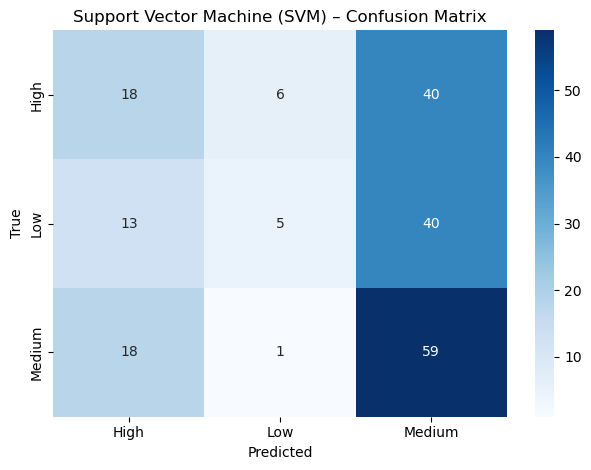


================ XGBoost Classifier ================
10-Fold CV Accuracy: 0.340 ± 0.038
ROC-AUC (macro): 0.527

Confusion Matrix:
 [[23 11 30]
 [15 13 30]
 [19 15 44]]

Classification Report:
               precision    recall  f1-score   support

        High      0.404     0.359     0.380        64
         Low      0.333     0.224     0.268        58
      Medium      0.423     0.564     0.484        78

    accuracy                          0.400       200
   macro avg      0.387     0.383     0.377       200
weighted avg      0.391     0.400     0.388       200



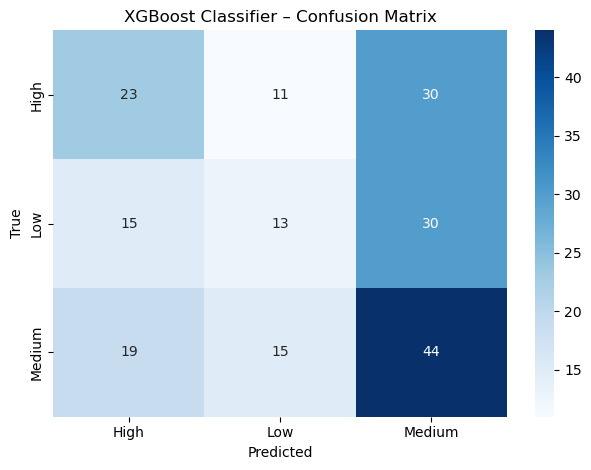


================ Logistic Regression Classifier ================
10-Fold CV Accuracy: 0.344 ± 0.073
ROC-AUC (macro): 0.503

Confusion Matrix:
 [[12  7 45]
 [10  4 44]
 [10  8 60]]

Classification Report:
               precision    recall  f1-score   support

        High      0.375     0.188     0.250        64
         Low      0.211     0.069     0.104        58
      Medium      0.403     0.769     0.529        78

    accuracy                          0.380       200
   macro avg      0.329     0.342     0.294       200
weighted avg      0.338     0.380     0.316       200



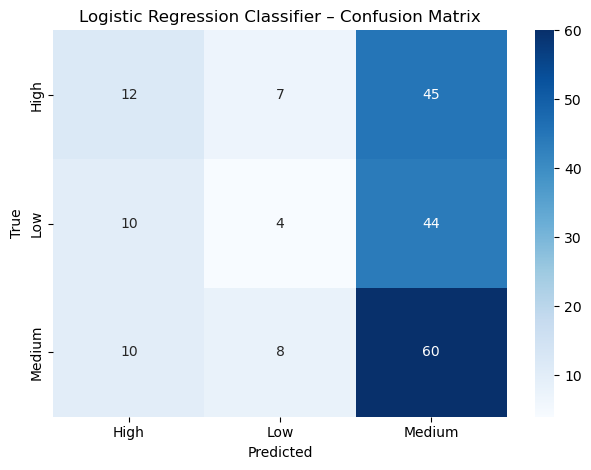


================ Hyperparameter Tuning ================

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best RF Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best RF CV Accuracy: 0.370

================ Tuned Random Forest Classifier ================
10-Fold CV Accuracy: 0.379 ± 0.039
ROC-AUC (macro): 0.525

Confusion Matrix:
 [[20  7 37]
 [17 11 30]
 [18  9 51]]

Classification Report:
               precision    recall  f1-score   support

        High      0.364     0.312     0.336        64
         Low      0.407     0.190     0.259        58
      Medium      0.432     0.654     0.520        78

    accuracy                          0.410       200
   macro avg      0.401     0.385     0.372       200
weighted avg      0.403     0.410     0.386       200



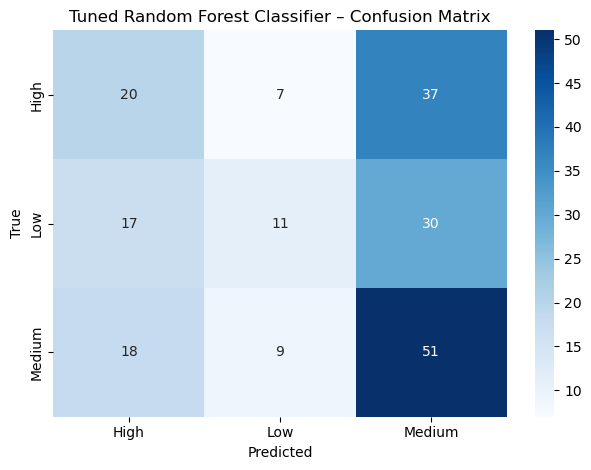

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best XGB CV Accuracy: 0.398

================ Tuned XGBoost Classifier ================


C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_labe

10-Fold CV Accuracy: 0.334 ± 0.029


C:\Users\Avangeline Kumar\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:48:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC (macro): 0.536

Confusion Matrix:
 [[20 10 34]
 [17 15 26]
 [25 17 36]]

Classification Report:
               precision    recall  f1-score   support

        High      0.323     0.312     0.317        64
         Low      0.357     0.259     0.300        58
      Medium      0.375     0.462     0.414        78

    accuracy                          0.355       200
   macro avg      0.352     0.344     0.344       200
weighted avg      0.353     0.355     0.350       200



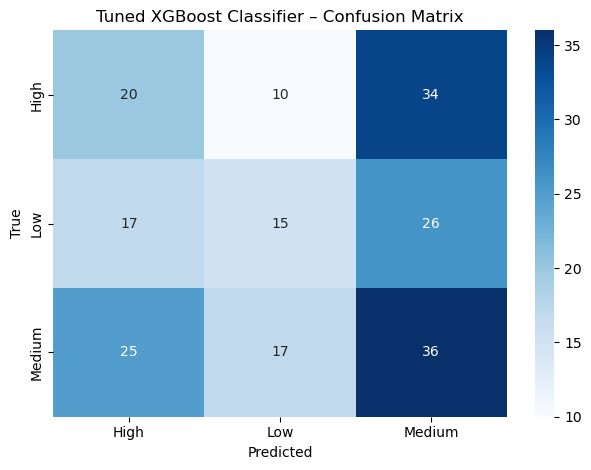

In [11]:
# === Sub-Problem B: Collapse Risk Classification (Feature-Optimized + ROC-AUC Fixed) ===
# Author: Team AfterShock

# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load Dataset ===
seismic_df = pd.read_csv("cleaned_seismic1.csv", encoding='ISO-8859-1')

# === 3. Create Target from Collapse Probability (%) ===
def classify_risk(prob):
    if prob < 30:
        return 'Low'
    elif 30 <= prob < 70:
        return 'Medium'
    elif prob >= 70:
        return 'High'
    else:
        return 'Error'

seismic_df['collapse_risk'] = seismic_df['Predicted Collapse Probability (%)'].apply(classify_risk)

# === 4. Define Inputs & Targets ===
# Use only top 10 most important features (from feature importance plot)
selected_features = [
    'Axial Stiffness (kN/m)',
    'Seismic Wave Frequency (Hz)',
    'Mass of Structure (kg)',
    'Bending Stiffness (kN·m²)',
    'Natural Frequency (Hz)',
    'Predicted Max Roof Displacement (m)',
    'Historical Earthquake Magnitude (Mw)',
    'Predicted Base Shear Force (kN)',
    'Predicted Max Inter-Story Drift Ratio (%)',
    'Spectral Acceleration (g)'
]

X_B = seismic_df[selected_features]
y_B_clf = seismic_df['collapse_risk']

# === 5. Encode Categorical Variables (if any) ===
X_B = pd.get_dummies(X_B, drop_first=True)

# === 6. Label Encode Target ===
le = LabelEncoder()
y_B_clf_encoded = le.fit_transform(y_B_clf)

# === 7. Train-Test Split ===
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B_clf_encoded, test_size=0.2, random_state=42, stratify=y_B_clf_encoded
)

# === 8. Feature Scaling (for SVM & Logistic Regression) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_B)
X_test_scaled = scaler.transform(X_test_B)

# === 9. Evaluation Function ===
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n================ {model_name} ================")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"10-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, digits=3)

    # ROC-AUC (macro)
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
            print(f"ROC-AUC (macro): {auc:.3f}")
        except Exception as e:
            print("ROC-AUC not available:", e)
    else:
        print("ROC-AUC not available (no predict_proba).")

    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} – Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# === 10. Train & Evaluate Each Model ===

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
evaluate_model(rf, X_train_B, X_test_B, y_train_B, y_test_B, "Random Forest Classifier")

# Support Vector Machine
svm = SVC(kernel='rbf', probability=True, random_state=42)
evaluate_model(svm, X_train_scaled, X_test_scaled, y_train_B, y_test_B, "Support Vector Machine (SVM)")

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
evaluate_model(xgb, X_train_B, X_test_B, y_train_B, y_test_B, "XGBoost Classifier")

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model(logreg, X_train_scaled, X_test_scaled, y_train_B, y_test_B, "Logistic Regression Classifier")

# === 11. Hyperparameter Tuning for Higher Accuracy ===
from sklearn.model_selection import GridSearchCV

print("\n================ Hyperparameter Tuning ================\n")

# === Random Forest Tuning ===
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_B, y_train_B)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Accuracy: {rf_grid.best_score_:.3f}")

# Re-train Random Forest with best params
best_rf = rf_grid.best_estimator_
evaluate_model(best_rf, X_train_B, X_test_B, y_train_B, y_test_B, "Tuned Random Forest Classifier")


# === XGBoost Tuning ===
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_B, y_train_B)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best XGB CV Accuracy: {xgb_grid.best_score_:.3f}")

# Re-train XGBoost with best params
best_xgb = xgb_grid.best_estimator_
evaluate_model(best_xgb, X_train_B, X_test_B, y_train_B, y_test_B, "Tuned XGBoost Classifier")


After SMOTE balancing: [390 390 390]

================ Random Forest (Class Balanced) ================
10-Fold CV Accuracy: 0.432 ± 0.045
ROC-AUC (macro): 0.643

Confusion Matrix:
 [[33 15 30]
 [11 48 19]
 [25 25 28]]

Classification Report:
               precision    recall  f1-score   support

        High      0.478     0.423     0.449        78
         Low      0.545     0.615     0.578        78
      Medium      0.364     0.359     0.361        78

    accuracy                          0.466       234
   macro avg      0.462     0.466     0.463       234
weighted avg      0.462     0.466     0.463       234



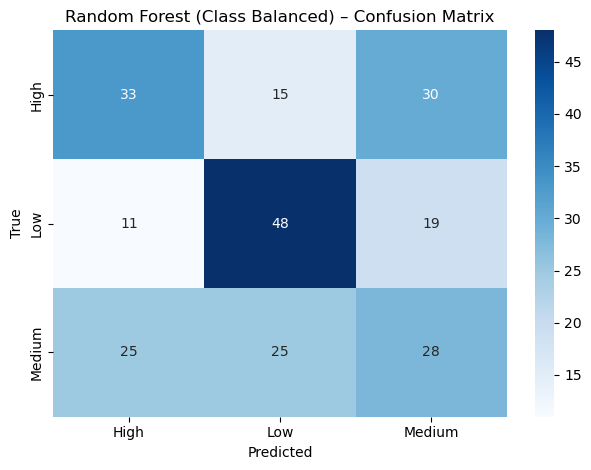


================ XGBoost (Class Balanced) ================
10-Fold CV Accuracy: 0.431 ± 0.051
ROC-AUC (macro): 0.619

Confusion Matrix:
 [[33 17 28]
 [12 45 21]
 [25 25 28]]

Classification Report:
               precision    recall  f1-score   support

        High      0.471     0.423     0.446        78
         Low      0.517     0.577     0.545        78
      Medium      0.364     0.359     0.361        78

    accuracy                          0.453       234
   macro avg      0.451     0.453     0.451       234
weighted avg      0.451     0.453     0.451       234



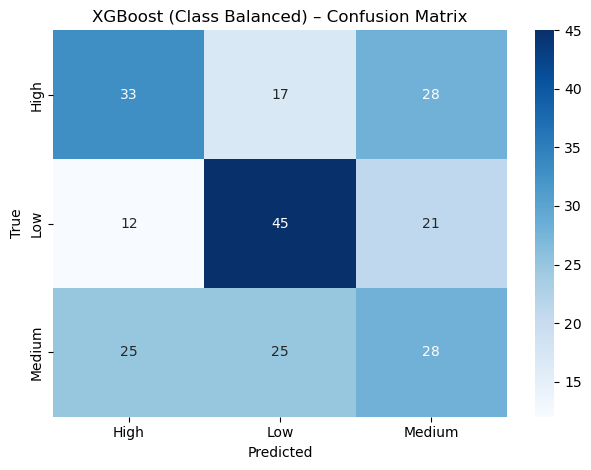


================ Hyperparameter Tuning ================

Fitting 5 folds for each of 162 candidates, totalling 810 fits


In [ ]:
# === Sub-Problem B: Collapse Risk Classification (Optimized, Balanced & Tuned) ===
# Author: Team AfterShock

# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load Dataset ===
seismic_df = pd.read_csv("cleaned_seismic1.csv", encoding='ISO-8859-1')

# === 3. Create Target from Collapse Probability (%) ===
def classify_risk(prob):
    if prob < 30:
        return 'Low'
    elif 30 <= prob < 70:
        return 'Medium'
    else:
        return 'High'

seismic_df['collapse_risk'] = seismic_df['Predicted Collapse Probability (%)'].apply(classify_risk)

# === 4. Select Top 10 Features (Based on Feature Importance Plot) ===
selected_features = [
    'Axial Stiffness (kN/m)', 'Seismic Wave Frequency (Hz)', 'Mass of Structure (kg)',
    'Bending Stiffness (kN·m²)', 'Natural Frequency (Hz)',
    'Predicted Max Roof Displacement (m)', 'Historical Earthquake Magnitude (Mw)',
    'Predicted Base Shear Force (kN)', 'Predicted Max Inter-Story Drift Ratio (%)',
    'Spectral Acceleration (g)'
]

X_B = seismic_df[selected_features]
y_B = seismic_df['collapse_risk']

# === 5. Encode Categorical Variables and Target ===
X_B = pd.get_dummies(X_B, drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y_B)

# === 6. Handle Class Imbalance with SMOTE ===
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_B, y_encoded)
print("After SMOTE balancing:", np.bincount(y_res))

# === 7. Train-Test Split === 
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# === 8. Feature Scaling (for SVM & Logistic Regression) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 9. Evaluation Function ===
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n================ {model_name} ================")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"10-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, digits=3)

    # ROC-AUC (macro)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        print(f"ROC-AUC (macro): {auc:.3f}")
    else:
        print("ROC-AUC not available (no predict_proba).")

    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} – Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# === 10. Baseline Models ===
rf = RandomForestClassifier(n_estimators=500, random_state=42)
evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest (Class Balanced)")

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='mlogloss'
)
evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost (Class Balanced)")

# === 11. Hyperparameter Tuning (Random Forest & XGBoost) ===
print("\n================ Hyperparameter Tuning ================\n")

# --- Random Forest Tuning ---
rf_param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Accuracy: {rf_grid.best_score_:.3f}")
best_rf = rf_grid.best_estimator_
evaluate_model(best_rf, X_train, X_test, y_train, y_test, "Tuned Random Forest (Class Balanced)")

# --- XGBoost Tuning ---
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best XGB CV Accuracy: {xgb_grid.best_score_:.3f}")
best_xgb = xgb_grid.best_estimator_
evaluate_model(best_xgb, X_train, X_test, y_train, y_test, "Tuned XGBoost (Class Balanced)")
